# Neural ODEs for Irregular Time Series

Every model in Chapter 11 so far assumes a fixed sampling rate. Real data is
often irregular: vitals charted when a nurse checks, sensors that drop
packets, events that arrive whenever a user acts. A **Neural ODE** sidesteps
the fixed grid: instead of a discrete recurrence, it learns the *derivative*
of a hidden state, `dz/dt = f(z)`, and an ODE solver integrates that
derivative to any timestamp you ask for.

This notebook fits a Neural ODE to a continuous system observed at a handful
of **unevenly spaced, noisy** timestamps, then queries the trained model on a
dense grid it never saw.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchdiffeq import odeint

torch.manual_seed(0)
np.random.seed(0)

## A continuous system, sampled irregularly

The ground truth is a damped linear spiral, `dz/dt = A z`. We integrate it on
a dense grid for reference, then keep only 40 randomly chosen, unevenly
spaced points and add observation noise. That irregular set is all the model
will see.

In [2]:
true_A = torch.tensor([[-0.1, 2.0], [-2.0, -0.1]])


def true_dynamics(t, z):
    return z @ true_A.T


z0 = torch.tensor([2.0, 0.0])
t_dense = torch.linspace(0.0, 15.0, 600)
with torch.no_grad():
    z_dense = odeint(true_dynamics, z0, t_dense)

n_obs = 40
idx = np.sort(np.random.choice(len(t_dense), n_obs, replace=False))
t_obs = t_dense[idx]
z_obs = z_dense[idx] + 0.03 * torch.randn(n_obs, 2)

gaps = torch.diff(t_obs)
print(f"{n_obs} observations spanning [{t_obs.min():.2f}, {t_obs.max():.2f}]")
print(f"gap between observations: min {gaps.min():.3f}, max {gaps.max():.3f}")

40 observations spanning [0.03, 14.87]
gap between observations: min 0.025, max 1.477


## The Neural ODE

`ODEFunc` is the learned derivative: a small MLP mapping the state to its
rate of change. `torchdiffeq.odeint` integrates it, and the solver is
differentiable, so the whole thing trains end to end with ordinary autograd.

In [3]:
class ODEFunc(nn.Module):
    """The learned derivative dz/dt."""

    def __init__(self, dim=2, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, dim),
        )

    def forward(self, t, z):
        return self.net(z)


func = ODEFunc()
opt = torch.optim.Adam(func.parameters(), lr=1e-2)

## Training on short sub-trajectories

Asking the solver to integrate the whole five-oscillation spiral in one shot
gives a loss surface full of bad minima. The fix, standard for Neural ODEs,
is to train on short windows. Each step picks a few observations at random as
starting points and integrates forward over only the next few timestamps. The
gaps inside every window are the real, irregular gaps, so the solver still
never touches a regular grid. Sweeping the start points across the whole
record teaches the derivative `f` everywhere along the timeline.

In [4]:
window = 5      # observations integrated per training window
batch = 8       # windows per iteration

for it in range(1, 1001):
    opt.zero_grad()
    starts = np.random.choice(n_obs - window, batch, replace=False)
    loss = 0.0
    for s in starts:
        t_win = t_obs[s:s + window] - t_obs[s]   # shift to start at 0
        pred = odeint(func, z_obs[s], t_win, method="rk4")
        loss = loss + ((pred - z_obs[s:s + window]) ** 2).mean()
    loss = loss / batch
    loss.backward()
    opt.step()
    if it % 200 == 0:
        print(f"iter {it:4d}  window loss {loss.item():.5f}")

iter  200  window loss 0.00449


iter  400  window loss 0.00361


iter  600  window loss 0.00217


iter  800  window loss 0.00285


iter 1000  window loss 0.00196


## Querying the model at arbitrary times

The learned derivative depends only on the state, so the short windows
compose into one global trajectory. We integrate from the first observation
across the dense grid, including all the times *between* observations that
the model never saw.

MSE against the true continuous trajectory: 0.07717


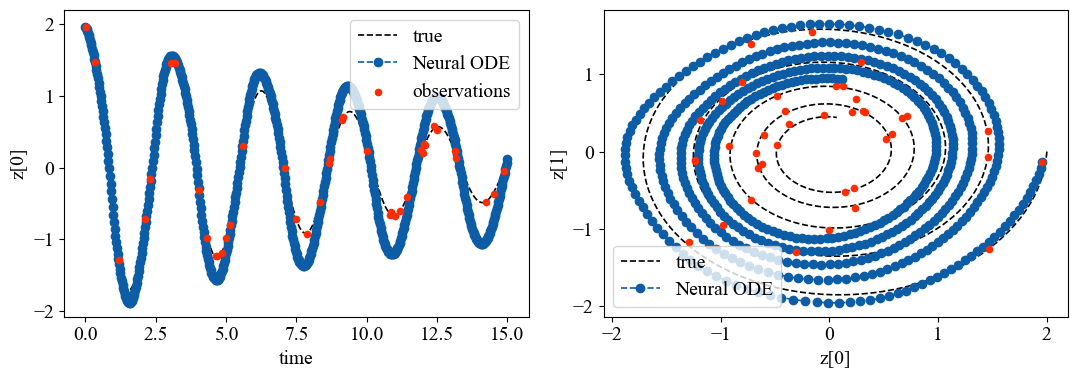

In [5]:
z0_obs = z_obs[0]
with torch.no_grad():
    z_fit = odeint(func, z0_obs, t_dense)
mse = ((z_fit - z_dense) ** 2).mean()
print(f"MSE against the true continuous trajectory: {mse.item():.5f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(t_dense, z_dense[:, 0], "k--", label="true")
ax[0].plot(t_dense, z_fit[:, 0], "C0", label="Neural ODE")
ax[0].scatter(t_obs, z_obs[:, 0], c="C3", s=20, zorder=3, label="observations")
ax[0].set_xlabel("time")
ax[0].set_ylabel("z[0]")
ax[0].legend()
ax[1].plot(z_dense[:, 0], z_dense[:, 1], "k--", label="true")
ax[1].plot(z_fit[:, 0], z_fit[:, 1], "C0", label="Neural ODE")
ax[1].scatter(z_obs[:, 0], z_obs[:, 1], c="C3", s=20, zorder=3)
ax[1].set_xlabel("z[0]")
ax[1].set_ylabel("z[1]")
ax[1].legend()
fig.tight_layout()
plt.show()

Trained on 40 irregular, noisy points, the Neural ODE recovers the continuous
trajectory and stays defined everywhere on the timeline. A full **Latent ODE**
wraps this core in an encoder over the observations and a decoder, but the
mechanism is the same: a learned derivative plus a solver that integrates to
whatever timestamp the data happens to carry.